# Pipeline Final - Acoes de Basquete com YOLO Pose

Este notebook consolida o fluxo final escolhido para entrega:

1. EDA do dataset e distribuicao das classes.
2. Criacao/validacao das features tabulares.
3. EDA das features selecionadas.
4. Treinamento supervisionado em 10 classes e 5 classes agrupadas.
5. Resultados supervisionados e matriz de confusao.
6. Treinamento nao supervisionado com KMeans e DBSCAN.
7. Visualizacao com PCA.

Decisao final: usar `all_v26` com as 80 features interpretaveis do `pruned_80`. As features refinadas foram testadas, mas o ganho foi muito pequeno para justificar maior dimensionalidade.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
    silhouette_score,
    v_measure_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parents[1]
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.config import GROUP_MAP, GROUP_ORDER, RANDOM_STATE

PYTHON = sys.executable
DATASET_PATH = ROOT_DIR / "data/processed/dataset_basquet_motion_stats_keypoints_semantic_pair_all_v26.csv"
MANIFEST_PATH = ROOT_DIR / "data/processed/yolo_pose_manifest_all_v26.csv"
FEATURE_LIST_PATH = ROOT_DIR / "results/feature_lists/feature_audit_semantic_pair_all_v26_original_pruned_80.txt"

TABLES_DIR = ROOT_DIR / "results/tables"
FIGURES_DIR = ROOT_DIR / "results/figures/final_pipeline"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUN_FEATURE_EXTRACTION = False
RUN_SUPERVISED = True
RUN_UNSUPERVISED = True
SKIP_EXISTING_RESULTS = False

MODEL_KEYS = ["logistic_regression", "decision_tree", "random_forest", "xgboost", "svc", "mlp"]
K_RANGE = range(2, 13)
SILHOUETTE_SAMPLE_SIZE = 5000
PCA_PLOT_SAMPLE_SIZE = 8000
DBSCAN_SAMPLE_SIZE = 8000
DBSCAN_MIN_SAMPLES_CANDIDATES = [10, 20]
DBSCAN_EPS_PERCENTILES = [80, 90, 95]

sns.set_theme(style="whitegrid")
print("ROOT_DIR:", ROOT_DIR)
print("PYTHON:", PYTHON)
print("DATASET_PATH:", DATASET_PATH.relative_to(ROOT_DIR))
print("FEATURE_LIST_PATH:", FEATURE_LIST_PATH.relative_to(ROOT_DIR))

ROOT_DIR: c:\Users\lf060\Documents\Position_Basquet_ML
PYTHON: c:\Users\lf060\Documents\Position_Basquet_ML\.venv\Scripts\python.exe
DATASET_PATH: data\processed\dataset_basquet_motion_stats_keypoints_semantic_pair_all_v26.csv
FEATURE_LIST_PATH: results\feature_lists\feature_audit_semantic_pair_all_v26_original_pruned_80.txt


## 1. EDA inicial

A primeira etapa verifica distribuicao das classes, agrupamentos semanticos e qualidade das poses extraidas. Usamos o dataset final se ele ja existir; caso contrario, o notebook pode gerar as features a partir do manifest YOLO.

In [2]:
if not DATASET_PATH.exists() and not RUN_FEATURE_EXTRACTION:
    raise FileNotFoundError(
        f"Dataset final nao encontrado: {DATASET_PATH}. "
        "Altere RUN_FEATURE_EXTRACTION=True para gerar as features."
    )

if MANIFEST_PATH.exists():
    manifest = pd.read_csv(MANIFEST_PATH, dtype={"sample_id": str})
    manifest["group_label"] = manifest.get("group_label", manifest["label"].map(GROUP_MAP))
    print("Manifest rows:", len(manifest))
    display(manifest["label"].value_counts().sort_index().to_frame("count"))
    display(manifest["group_label"].value_counts().reindex(GROUP_ORDER).to_frame("count"))
else:
    print("Manifest nao encontrado; seguindo com dataset final.")

Manifest rows: 37085


,count
label,
ball in hand,2362
block,996
defense,3866
dribble,3490
no_action,6490
pass,1070
pick,712
run,5924
shoot,426


,count
group_label,
ball_control,6922
defensive_action,5574
locomotion,17673
no_action,6490
shoot,426


## 2. Criacao ou carregamento das features

As features finais foram criadas a partir de keypoints normalizados: movimento, deltas, angulos, postura, features semanticas e features focadas em pares criticos. Para evitar uma execucao longa desnecessaria, a extracao so roda se `RUN_FEATURE_EXTRACTION=True` ou se o dataset final nao existir.

In [3]:
if RUN_FEATURE_EXTRACTION or not DATASET_PATH.exists():
    cmd = [
        PYTHON,
        "src/extract_temporal_keypoint_features.py",
        "--manifest", str(MANIFEST_PATH),
        "--output-name", "dataset_basquet_motion_stats_keypoints_semantic_pair_all_v26",
        "--no-snapshots",
        "--include-motion-deltas",
        "--include-motion-stats",
        "--include-angle-stats",
        "--include-posture-stats",
        "--include-semantic-stats",
        "--include-pair-critical-stats",
    ]
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=ROOT_DIR, check=True)
else:
    print("Pulando extracao: dataset final ja existe.")

data = pd.read_csv(DATASET_PATH, dtype={"sample_id": str})
data["group_label"] = data.get("group_label", data["label"].map(GROUP_MAP))
if "group_id" not in data.columns:
    group_to_id = {label: idx for idx, label in enumerate(GROUP_ORDER)}
    data["group_id"] = data["group_label"].map(group_to_id)

quality_data = data.copy()
if "quality_flag" in data.columns:
    data = data[~data["quality_flag"].astype(bool)].copy()

features = [line.strip() for line in FEATURE_LIST_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
missing_features = [feature for feature in features if feature not in data.columns]
if missing_features:
    raise ValueError(f"Features ausentes no dataset: {missing_features[:10]}")

print("Linhas totais:", len(quality_data))
print("Linhas apos filtro de qualidade:", len(data))
print("Features selecionadas:", len(features))

Pulando extracao: dataset final ja existe.
Linhas totais: 37085
Linhas apos filtro de qualidade: 35586
Features selecionadas: 80


## 3. EDA das features e distribuicao final

Aqui analisamos o dataset depois do filtro de qualidade e a composicao das 80 features selecionadas.

,label,count
0,ball in hand,2257
1,block,925
2,defense,3733
3,dribble,3293
4,no_action,6251
5,pass,1013
6,pick,695
7,run,5657
8,shoot,391
9,walk,11371


,group_label,count
0,ball_control,6563
1,defensive_action,5353
2,locomotion,17028
3,no_action,6251
4,shoot,391


,feature_group,count
0,angle,22
1,semantic,16
2,pair_critical,14
3,posture,10
4,motion_stats,9
5,motion_delta,9


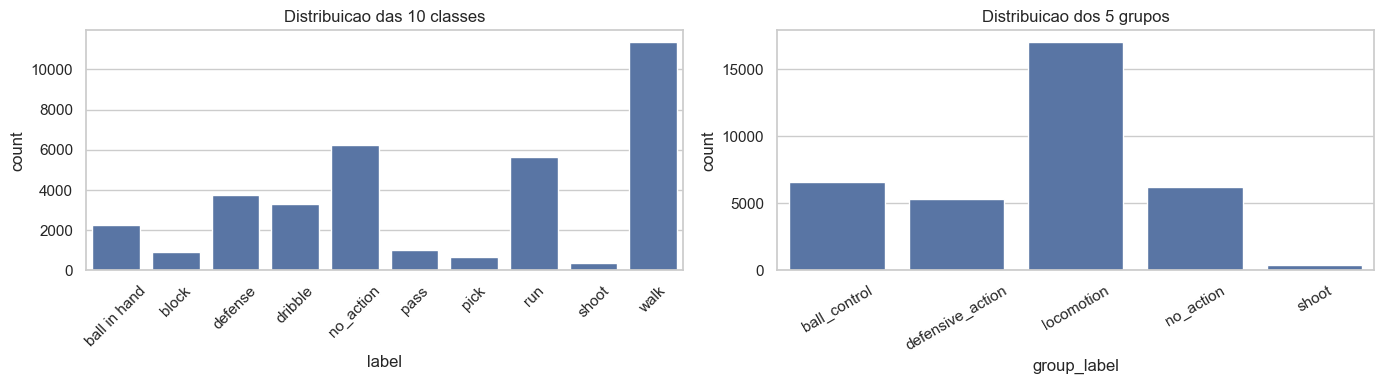

In [4]:
def feature_group(feature):
    if feature.startswith("delta_"):
        return "motion_delta"
    if feature.startswith("motion_"):
        return "motion_stats"
    if feature.startswith("angle_"):
        return "angle"
    if feature.startswith("semantic_"):
        return "semantic"
    if feature.startswith("pair_"):
        return "pair_critical"
    if feature.startswith("refined_"):
        return "refined_action"
    if (
        feature.startswith("dist_")
        or feature.startswith("arm_opening")
        or feature.startswith("leg_opening")
        or feature.startswith("hands_relative_height")
        or feature.startswith("wrist_above")
    ):
        return "posture"
    return "other"

class_dist = data["label"].value_counts().sort_index().rename_axis("label").reset_index(name="count")
group_dist = data["group_label"].value_counts().reindex(GROUP_ORDER).rename_axis("group_label").reset_index(name="count")
feature_groups = pd.Series(features).map(feature_group).value_counts().rename_axis("feature_group").reset_index(name="count")

class_dist.to_csv(TABLES_DIR / "final_eda_class_distribution.csv", index=False)
group_dist.to_csv(TABLES_DIR / "final_eda_group_distribution.csv", index=False)
feature_groups.to_csv(TABLES_DIR / "final_feature_group_distribution.csv", index=False)

display(class_dist)
display(group_dist)
display(feature_groups)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=class_dist, x="label", y="count", ax=axes[0])
axes[0].set_title("Distribuicao das 10 classes")
axes[0].tick_params(axis="x", rotation=45)
sns.barplot(data=group_dist, x="group_label", y="count", ax=axes[1])
axes[1].set_title("Distribuicao dos 5 grupos")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "final_class_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Treinamento supervisionado

Rodamos os 6 modelos classicos individuais exigidos para a entrega: Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM (SVC) e MLP. A metrica principal e `f1_macro`, pois o dataset e desbalanceado. O executor tambem salva as metricas obrigatorias e a matriz de confusao para cada modelo.

In [5]:
supervised_tests = [
    {
        "experiment": "final_10_classes_pruned80_all_v26",
        "target": "original",
    },
    {
        "experiment": "final_grouped_pruned80_all_v26",
        "target": "grouped",
    },
]

if RUN_SUPERVISED:
    for test in supervised_tests:
        result_path = TABLES_DIR / f"classification_results_{test['experiment']}.csv"
        if SKIP_EXISTING_RESULTS and result_path.exists():
            print(f"Pulando {test['experiment']}; resultado ja existe.")
            continue
        cmd = [
            PYTHON,
            "src/run_classification_experiment.py",
            "--dataset", str(DATASET_PATH),
            "--target", test["target"],
            "--experiment-name", test["experiment"],
            "--feature-list", str(FEATURE_LIST_PATH),
            "--models", *MODEL_KEYS,
        ]
        print(" ".join(cmd))
        subprocess.run(cmd, cwd=ROOT_DIR, check=True)
else:
    print("RUN_SUPERVISED = False")

c:\Users\lf060\Documents\Position_Basquet_ML\.venv\Scripts\python.exe src/run_classification_experiment.py --dataset c:\Users\lf060\Documents\Position_Basquet_ML\data\processed\dataset_basquet_motion_stats_keypoints_semantic_pair_all_v26.csv --target original --experiment-name final_10_classes_pruned80_all_v26 --feature-list c:\Users\lf060\Documents\Position_Basquet_ML\results\feature_lists\feature_audit_semantic_pair_all_v26_original_pruned_80.txt --models logistic_regression decision_tree random_forest xgboost svc mlp
c:\Users\lf060\Documents\Position_Basquet_ML\.venv\Scripts\python.exe src/run_classification_experiment.py --dataset c:\Users\lf060\Documents\Position_Basquet_ML\data\processed\dataset_basquet_motion_stats_keypoints_semantic_pair_all_v26.csv --target grouped --experiment-name final_grouped_pruned80_all_v26 --feature-list c:\Users\lf060\Documents\Position_Basquet_ML\results\feature_lists\feature_audit_semantic_pair_all_v26_original_pruned_80.txt --models logistic_regress

## 5. Resultados supervisionados

A tabela abaixo seleciona o melhor modelo por `f1_macro` em cada tarefa.

In [6]:
supervised_rows = []
all_supervised = []
for test in supervised_tests:
    path = TABLES_DIR / f"classification_results_{test['experiment']}.csv"
    result = pd.read_csv(path)
    result["task"] = test["target"]
    all_supervised.append(result)
    best = result.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0]
    supervised_rows.append(best)

supervised_results = pd.concat(all_supervised, ignore_index=True)
best_supervised = pd.DataFrame(supervised_rows)
supervised_results.to_csv(TABLES_DIR / "final_supervised_all_results.csv", index=False)
best_supervised.to_csv(TABLES_DIR / "final_supervised_best_results.csv", index=False)

display(supervised_results[["task", "model", "accuracy", "precision_macro", "recall_macro", "f1_macro", "feature_count"]].sort_values(["task", "f1_macro"], ascending=[True, False]))
display(best_supervised[["task", "model", "accuracy", "precision_macro", "recall_macro", "f1_macro", "feature_count"]])

,task,model,accuracy,precision_macro,recall_macro,f1_macro,feature_count
6,grouped,XGBoost,0.603821,0.513269,0.558353,0.530691,80
7,grouped,SVM (SVC),0.569963,0.472716,0.548749,0.492850,80
8,grouped,MLP,0.547204,0.451422,0.561013,0.465198,80
9,grouped,Random Forest,0.610284,0.665464,0.408553,0.448274,80
10,grouped,Logistic Regression,0.498736,0.419873,0.545668,0.419793,80
11,grouped,Decision Tree,0.480191,0.394043,0.384344,0.388759,80
0,original,XGBoost,0.517842,0.416219,0.447610,0.427195,80
1,original,SVM (SVC),0.479770,0.381042,0.450907,0.396645,80
2,original,MLP,0.452796,0.360522,0.430320,0.368580,80
3,original,Random Forest,0.511661,0.578607,0.316105,0.339146,80


,task,model,accuracy,precision_macro,recall_macro,f1_macro,feature_count
0,original,XGBoost,0.517842,0.416219,0.447610,0.427195,80
0,grouped,XGBoost,0.603821,0.513269,0.558353,0.530691,80


In [7]:
for test in supervised_tests:
    report_path = TABLES_DIR / f"classification_report_best_model_{test['experiment']}.csv"
    if report_path.exists():
        print("\n===", test["experiment"], "===")
        report = pd.read_csv(report_path, index_col=0)
        display(report[["precision", "recall", "f1-score", "support"]].round(4))


=== final_10_classes_pruned80_all_v26 ===


,precision,recall,f1-score,support
block,0.3490,0.5622,0.4306,185.0000
pass,0.2007,0.2759,0.2324,203.0000
run,0.5242,0.6131,0.5651,1132.0000
dribble,0.3944,0.3627,0.3779,659.0000
shoot,0.3750,0.3846,0.3797,78.0000
ball in hand,0.3915,0.4080,0.3996,451.0000
defense,0.4688,0.4726,0.4707,747.0000
pick,0.2026,0.2230,0.2123,139.0000
no_action,0.5907,0.6592,0.6231,1250.0000
walk,0.6653,0.5150,0.5806,2274.0000



=== final_grouped_pruned80_all_v26 ===


,precision,recall,f1-score,support
ball_control,0.4601,0.4912,0.4751,1313.0000
defensive_action,0.4937,0.5098,0.5016,1071.0000
locomotion,0.7491,0.6468,0.6942,3406.0000
no_action,0.5592,0.6952,0.6198,1250.0000
shoot,0.3043,0.4487,0.3627,78.0000
accuracy,0.6038,0.6038,0.6038,0.6038
macro avg,0.5133,0.5584,0.5307,7118.0000
weighted avg,0.6191,0.6038,0.6081,7118.0000


## 6. Treinamento nao supervisionado

KMeans e DBSCAN usam as 80 features padronizadas. As labels so aparecem depois, para avaliar se os clusters se parecem com classes reais.

In [8]:
X = data[features].copy()
y_original = data["label"].astype(str).copy()
y_grouped = data["group_label"].astype(str).copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(imputer.fit_transform(X))
print("X_scaled:", X_scaled.shape)

X_scaled: (35586, 80)


In [9]:
def cluster_purity(labels_true, labels_pred):
    contingency = pd.crosstab(pd.Series(labels_pred, name="cluster"), pd.Series(labels_true, name="label"))
    if contingency.empty:
        return np.nan
    return float(contingency.max(axis=1).sum() / contingency.values.sum())


def external_metrics(labels_true, labels_pred, name):
    return {
        "target": name,
        "adjusted_rand": adjusted_rand_score(labels_true, labels_pred),
        "normalized_mutual_info": normalized_mutual_info_score(labels_true, labels_pred),
        "homogeneity": homogeneity_score(labels_true, labels_pred),
        "completeness": completeness_score(labels_true, labels_pred),
        "v_measure": v_measure_score(labels_true, labels_pred),
        "purity": cluster_purity(labels_true, labels_pred),
    }

In [10]:
rng = np.random.default_rng(RANDOM_STATE)
silhouette_size = min(SILHOUETTE_SAMPLE_SIZE, X_scaled.shape[0])
silhouette_idx = rng.choice(X_scaled.shape[0], size=silhouette_size, replace=False)

if RUN_UNSUPERVISED:
    k_rows = []
    for k in K_RANGE:
        model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
        clusters = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled[silhouette_idx], clusters[silhouette_idx])
        k_rows.append({"k": k, "inertia": model.inertia_, "silhouette": sil})
    k_selection = pd.DataFrame(k_rows)
    best_k = int(k_selection.sort_values("silhouette", ascending=False).iloc[0]["k"])
    k_selection.to_csv(TABLES_DIR / "final_unsupervised_kmeans_k_selection.csv", index=False)
    display(k_selection)
    print("K selecionado por silhouette:", best_k)
else:
    best_k = 2
    k_selection = pd.DataFrame()

,k,inertia,silhouette
0,2,2.595155e+06,0.180381
1,3,2.391663e+06,0.164670
2,4,2.295364e+06,0.114483
3,5,2.205397e+06,0.119105
4,6,2.125390e+06,0.086293
5,7,2.059100e+06,0.088487
6,8,2.024462e+06,0.081098
7,9,1.984188e+06,0.044921
8,10,1.953710e+06,0.040076
9,11,1.920060e+06,0.044940


K selecionado por silhouette: 2


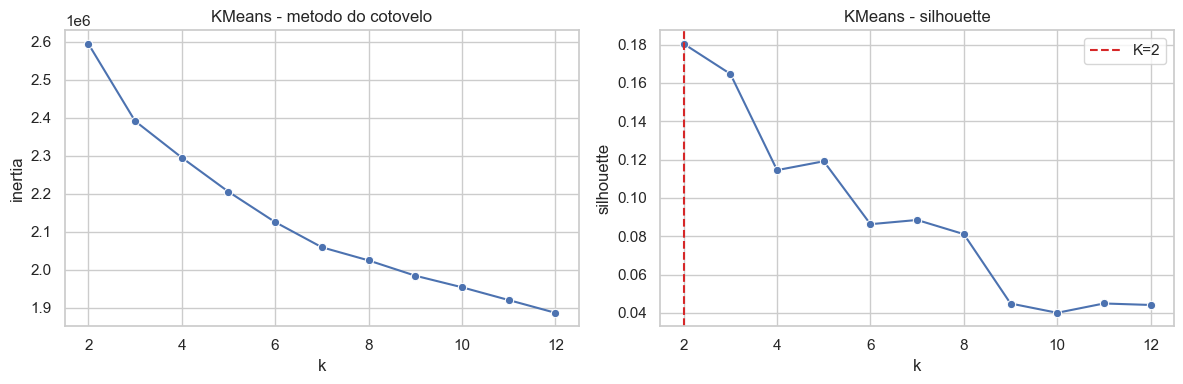

,target,adjusted_rand,normalized_mutual_info,homogeneity,completeness,v_measure,purity,k,silhouette_sample
0,original_10_classes,0.076441,0.075950,0.051073,0.148078,0.075950,0.318308,2,0.180381
1,grouped_5_classes,0.046225,0.056299,0.042415,0.083695,0.056299,0.480349,2,0.180381


In [11]:
if RUN_UNSUPERVISED:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.lineplot(data=k_selection, x="k", y="inertia", marker="o", ax=axes[0])
    axes[0].set_title("KMeans - metodo do cotovelo")
    sns.lineplot(data=k_selection, x="k", y="silhouette", marker="o", ax=axes[1])
    axes[1].axvline(best_k, color="tab:red", linestyle="--", label=f"K={best_k}")
    axes[1].set_title("KMeans - silhouette")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "final_kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
    plt.show()

    kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE)
    kmeans_clusters = kmeans.fit_predict(X_scaled)
    data["cluster_kmeans"] = kmeans_clusters

    kmeans_metrics = pd.DataFrame([
        external_metrics(y_original, kmeans_clusters, "original_10_classes"),
        external_metrics(y_grouped, kmeans_clusters, "grouped_5_classes"),
    ])
    kmeans_metrics["k"] = best_k
    kmeans_metrics["silhouette_sample"] = silhouette_score(X_scaled[silhouette_idx], kmeans_clusters[silhouette_idx])
    kmeans_metrics.to_csv(TABLES_DIR / "final_unsupervised_kmeans_metrics.csv", index=False)
    pd.crosstab(data["cluster_kmeans"], y_original, normalize="index").to_csv(TABLES_DIR / "final_unsupervised_kmeans_contingency_original.csv")
    pd.crosstab(data["cluster_kmeans"], y_grouped, normalize="index").to_csv(TABLES_DIR / "final_unsupervised_kmeans_contingency_grouped.csv")
    display(kmeans_metrics)
else:
    kmeans_clusters = np.zeros(len(data), dtype=int)
    kmeans_metrics = pd.DataFrame()

## 7. DBSCAN

DBSCAN e executado em amostra por custo computacional. No nosso resultado, a tendencia foi formar um cluster unico com poucos outliers, o que indica sobreposicao forte no espaco de features.

In [12]:
if RUN_UNSUPERVISED:
    dbscan_size = min(DBSCAN_SAMPLE_SIZE, X_scaled.shape[0])
    dbscan_idx = rng.choice(X_scaled.shape[0], size=dbscan_size, replace=False)
    X_dbscan = X_scaled[dbscan_idx]
    labels_original_dbscan = y_original.iloc[dbscan_idx].reset_index(drop=True)
    labels_grouped_dbscan = y_grouped.iloc[dbscan_idx].reset_index(drop=True)

    eps_candidates = set()
    for min_samples in DBSCAN_MIN_SAMPLES_CANDIDATES:
        nn = NearestNeighbors(n_neighbors=min_samples, n_jobs=-1)
        distances, _ = nn.fit(X_dbscan).kneighbors(X_dbscan)
        kth_distances = distances[:, -1]
        for percentile in DBSCAN_EPS_PERCENTILES:
            eps_candidates.add(round(float(np.percentile(kth_distances, percentile)), 4))
    eps_candidates = sorted(eps_candidates)

    dbscan_rows = []
    for eps in eps_candidates:
        for min_samples in DBSCAN_MIN_SAMPLES_CANDIDATES:
            clusters = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit_predict(X_dbscan)
            non_noise = clusters != -1
            n_clusters = len(set(clusters) - {-1})
            noise_ratio = float(np.mean(clusters == -1))
            sil = np.nan
            if n_clusters >= 2 and non_noise.sum() > n_clusters:
                sil = silhouette_score(X_dbscan[non_noise], clusters[non_noise])
            dbscan_rows.append({
                "eps": eps,
                "min_samples": min_samples,
                "sample_rows": len(X_dbscan),
                "n_clusters": n_clusters,
                "noise_ratio": noise_ratio,
                "silhouette_non_noise": sil,
                "ari_original": adjusted_rand_score(labels_original_dbscan, clusters),
                "nmi_original": normalized_mutual_info_score(labels_original_dbscan, clusters),
                "ari_grouped": adjusted_rand_score(labels_grouped_dbscan, clusters),
                "nmi_grouped": normalized_mutual_info_score(labels_grouped_dbscan, clusters),
            })

    dbscan_grid = pd.DataFrame(dbscan_rows)
    valid = dbscan_grid[(dbscan_grid["n_clusters"] >= 2) & (dbscan_grid["noise_ratio"] <= 0.80)].copy()
    if valid.empty:
        best_dbscan = dbscan_grid.sort_values(["n_clusters", "noise_ratio"], ascending=[False, True]).iloc[0]
    else:
        best_dbscan = valid.sort_values(["silhouette_non_noise", "nmi_grouped"], ascending=False).iloc[0]

    best_eps = float(best_dbscan["eps"])
    best_min_samples = int(best_dbscan["min_samples"])
    dbscan_clusters = DBSCAN(eps=best_eps, min_samples=best_min_samples, n_jobs=-1).fit_predict(X_dbscan)

    dbscan_result = pd.DataFrame({
        "sample_id": data.iloc[dbscan_idx]["sample_id"].to_numpy(),
        "label": labels_original_dbscan.to_numpy(),
        "group_label": labels_grouped_dbscan.to_numpy(),
        "cluster_dbscan": dbscan_clusters,
    })
    dbscan_metrics = pd.DataFrame([
        external_metrics(labels_original_dbscan, dbscan_clusters, "original_10_classes"),
        external_metrics(labels_grouped_dbscan, dbscan_clusters, "grouped_5_classes"),
    ])
    dbscan_metrics["eps"] = best_eps
    dbscan_metrics["min_samples"] = best_min_samples
    dbscan_metrics["rows"] = len(dbscan_clusters)
    dbscan_metrics["n_clusters"] = len(set(dbscan_clusters) - {-1})
    dbscan_metrics["noise_ratio"] = float(np.mean(dbscan_clusters == -1))

    dbscan_grid.to_csv(TABLES_DIR / "final_unsupervised_dbscan_grid.csv", index=False)
    dbscan_result.to_csv(TABLES_DIR / "final_unsupervised_dbscan_assignments.csv", index=False)
    dbscan_metrics.to_csv(TABLES_DIR / "final_unsupervised_dbscan_metrics.csv", index=False)
    pd.crosstab(dbscan_result["cluster_dbscan"], dbscan_result["label"], normalize="index").to_csv(TABLES_DIR / "final_unsupervised_dbscan_contingency_original.csv")
    pd.crosstab(dbscan_result["cluster_dbscan"], dbscan_result["group_label"], normalize="index").to_csv(TABLES_DIR / "final_unsupervised_dbscan_contingency_grouped.csv")

    display(dbscan_grid)
    display(dbscan_metrics)
else:
    dbscan_idx = np.arange(min(DBSCAN_SAMPLE_SIZE, X_scaled.shape[0]))
    dbscan_clusters = np.zeros(len(dbscan_idx), dtype=int)
    best_eps = np.nan
    best_min_samples = np.nan
    dbscan_metrics = pd.DataFrame()

,eps,min_samples,sample_rows,n_clusters,noise_ratio,silhouette_non_noise,ari_original,nmi_original,ari_grouped,nmi_grouped
0,6.6530,10,8000,1,0.127875,NaN,0.031125,0.023520,0.034967,0.023974
1,6.6530,20,8000,1,0.137500,NaN,0.034562,0.026552,0.039932,0.027044
2,6.9833,10,8000,1,0.102250,NaN,0.024823,0.018278,0.029726,0.018444
3,6.9833,20,8000,1,0.112250,NaN,0.029147,0.022685,0.035711,0.022859
4,7.8928,10,8000,1,0.054500,NaN,0.011078,0.007488,0.013521,0.007138
5,7.8928,20,8000,1,0.059375,NaN,0.013131,0.009529,0.017173,0.009626
6,8.2482,10,8000,1,0.045250,NaN,0.008449,0.005472,0.011020,0.005419
7,8.2482,20,8000,1,0.049750,NaN,0.010394,0.007916,0.013968,0.007848
8,9.0731,10,8000,1,0.029750,NaN,0.004095,0.003085,0.005772,0.002560
9,9.0731,20,8000,1,0.030875,NaN,0.004742,0.003299,0.006387,0.002908


,target,adjusted_rand,normalized_mutual_info,homogeneity,completeness,v_measure,purity,eps,min_samples,rows,n_clusters,noise_ratio
0,original_10_classes,0.002130,0.002077,0.001100,0.018631,0.002077,0.316750,9.5431,10,8000,1,0.023875
1,grouped_5_classes,0.002972,0.001515,0.000823,0.009505,0.001515,0.479875,9.5431,10,8000,1,0.023875


## 8. PCA para visualizacao

PCA nao e usado para treinar os modelos. Ele serve para visualizar a sobreposicao das classes e dos clusters.

In [13]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)
pca_variance = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
})
pca_variance.to_csv(TABLES_DIR / "final_pca_explained_variance.csv", index=False)
display(pca_variance)
print("PC1 + PC2:", float(pca.explained_variance_ratio_.sum()))

,component,explained_variance_ratio
0,PC1,0.155034
1,PC2,0.104303


PC1 + PC2: 0.25933733000281417


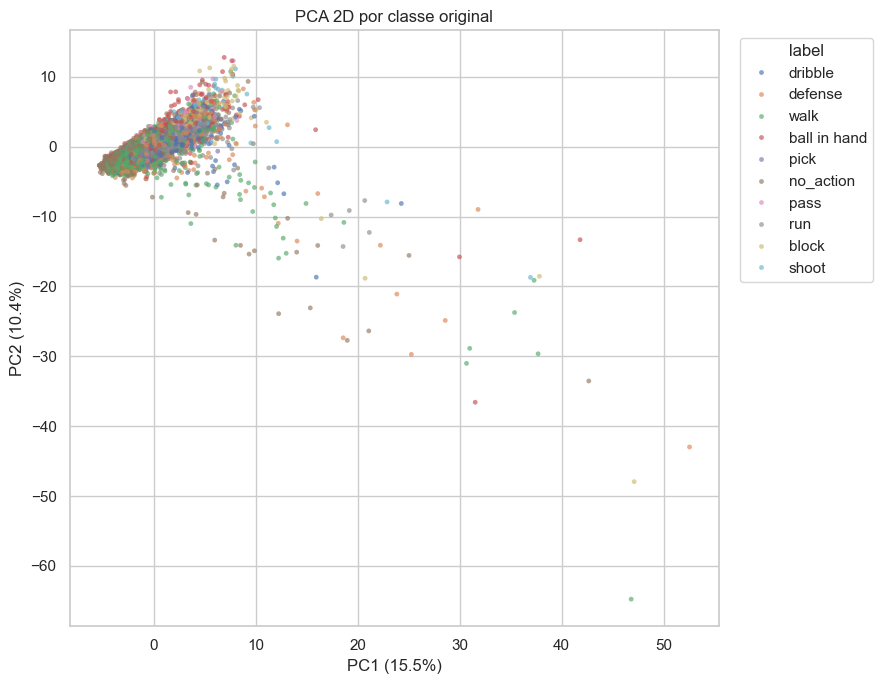

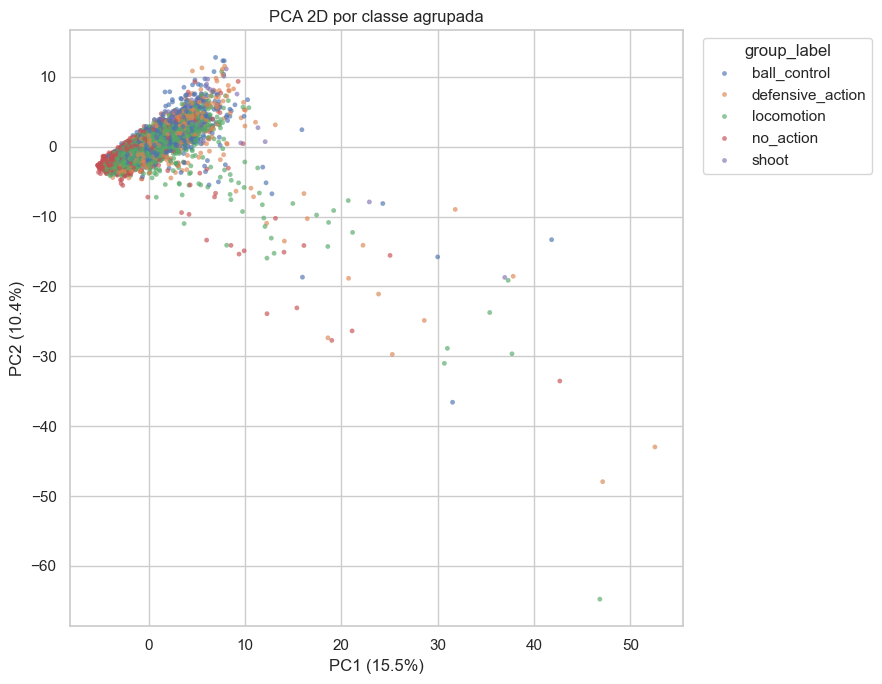

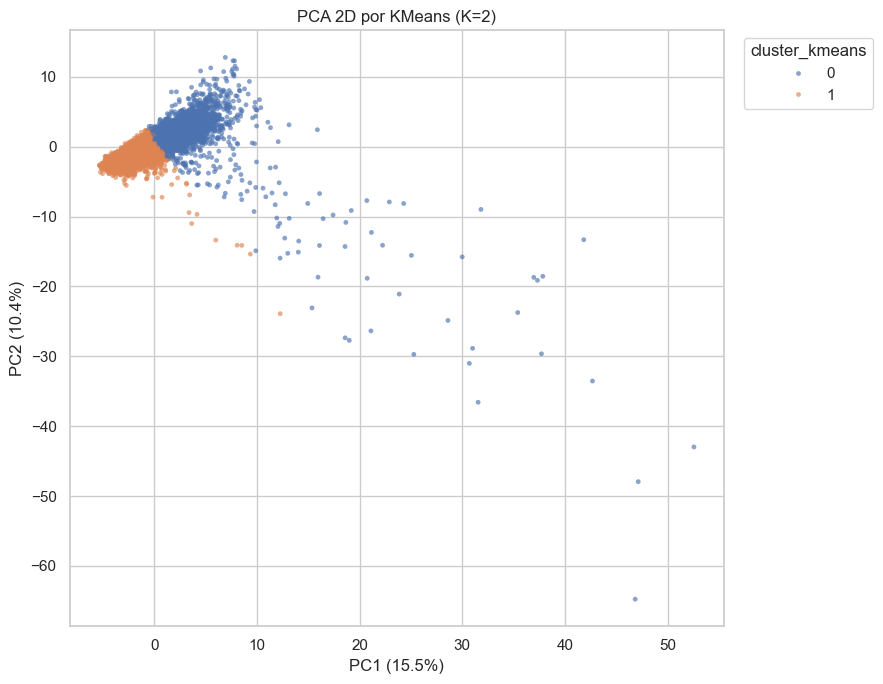

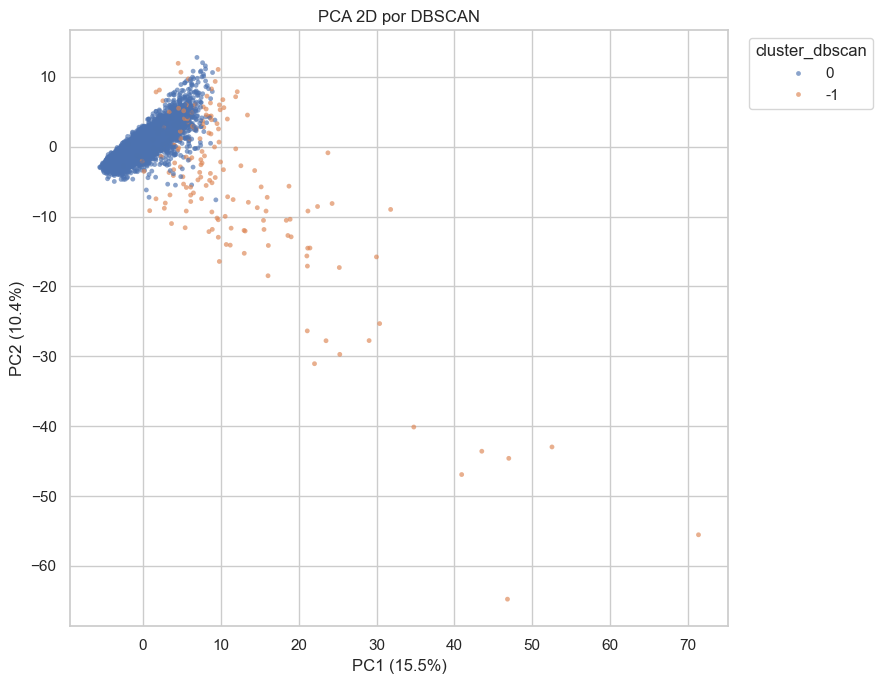

In [14]:
plot_size = min(PCA_PLOT_SAMPLE_SIZE, X_scaled.shape[0])
plot_idx = rng.choice(X_scaled.shape[0], size=plot_size, replace=False)
plot_df = pd.DataFrame({
    "PC1": pca_coords[plot_idx, 0],
    "PC2": pca_coords[plot_idx, 1],
    "label": y_original.iloc[plot_idx].to_numpy(),
    "group_label": y_grouped.iloc[plot_idx].to_numpy(),
    "cluster_kmeans": kmeans_clusters[plot_idx].astype(str),
})

dbscan_pca = pca.transform(X_scaled[dbscan_idx])
dbscan_plot_df = pd.DataFrame({
    "PC1": dbscan_pca[:, 0],
    "PC2": dbscan_pca[:, 1],
    "cluster_dbscan": dbscan_clusters.astype(str),
})

def save_pca_scatter(df, hue, title, filename, max_legend_items=12):
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.scatterplot(data=df, x="PC1", y="PC2", hue=hue, s=12, alpha=0.65, linewidth=0, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
    handles, labels = ax.get_legend_handles_labels()
    if len(labels) > max_legend_items:
        ax.legend(handles[:max_legend_items], labels[:max_legend_items], title=hue, bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        ax.legend(title=hue, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

save_pca_scatter(plot_df, "label", "PCA 2D por classe original", "final_pca_original_labels.png")
save_pca_scatter(plot_df, "group_label", "PCA 2D por classe agrupada", "final_pca_grouped_labels.png")
save_pca_scatter(plot_df, "cluster_kmeans", f"PCA 2D por KMeans (K={best_k})", "final_pca_kmeans_clusters.png")
save_pca_scatter(dbscan_plot_df, "cluster_dbscan", "PCA 2D por DBSCAN", "final_pca_dbscan_clusters.png")

## 9. Resumo final

Este resumo consolida os principais artefatos gerados pelo notebook.

In [15]:
summary = {
    "dataset": str(DATASET_PATH.relative_to(ROOT_DIR)),
    "feature_list": str(FEATURE_LIST_PATH.relative_to(ROOT_DIR)),
    "rows_after_quality_filter": int(len(data)),
    "feature_count": int(len(features)),
    "supervised_models": MODEL_KEYS,
    "metric_priority": "f1_macro",
    "kmeans_best_k": int(best_k),
    "dbscan_eps": None if pd.isna(best_eps) else float(best_eps),
    "dbscan_min_samples": None if pd.isna(best_min_samples) else int(best_min_samples),
    "pca_pc1_pc2_variance": float(pca.explained_variance_ratio_.sum()),
    "main_interpretation": "Classes e clusters ficam sobrepostos; pose 2D sem bola/cesta/adversario limita a separacao.",
}
summary_path = TABLES_DIR / "final_pipeline_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "dataset": "data\\processed\\dataset_basquet_motion_stats_keypoints_semantic_pair_all_v26.csv",
  "feature_list": "results\\feature_lists\\feature_audit_semantic_pair_all_v26_original_pruned_80.txt",
  "rows_after_quality_filter": 35586,
  "feature_count": 80,
  "supervised_models": [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "xgboost",
    "svc",
    "mlp"
  ],
  "metric_priority": "f1_macro",
  "kmeans_best_k": 2,
  "dbscan_eps": 9.5431,
  "dbscan_min_samples": 10,
  "pca_pc1_pc2_variance": 0.25933733000281417,
  "main_interpretation": "Classes e clusters ficam sobrepostos; pose 2D sem bola/cesta/adversario limita a separacao."
}
